# Model Benchmark — XGBoost vs Random Forest vs LSTM for CIT Prediction

Formalizes the model comparison already sketched in `09_cit_ranking_baseline.ipynb`
section 9 into a standalone, reusable benchmark: same leak-free feature matrix
(`cpht_features.build_cit_feature_matrix`), same chronological 80/20 split, but with
saved model artifacts, an exported metrics table, and time-series cross-validation
for all three models (not just Random Forest).

**Purpose:** benchmark the models *honestly* against a **persistence baseline**
using **walk-forward CV** (not just one 80/20 split), so we know whether the ML
adds real out-of-sample skill or is merely riding on `CIT_lag1`. The fitted
XGBoost/RandomForest are still handed to `6b` for **SHAP HX→CIT attribution**,
but this notebook is explicit that they are attribution tools, not validated
point-forecasters (see the honest Summary at the bottom).

Sections:
1. Load leak-free feature matrix (shared `cpht_features` module)
2. Chronological train/test split
3. Train XGBoost, RandomForest, LSTM
4. Metrics comparison (R2, RMSE, MAE, MAPE, within-10C hit rate)
5. Actual-vs-predicted plots
6. Time-series cross-validation (5-fold, all 3 models)
7. Save model artifacts + export `Model_Comparison_Metrics.csv`

## 0. Imports & Configuration

In [1]:
import warnings, os, sys
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import joblib
from pathlib import Path

sys.path.append(str(Path.cwd()))
from cpht_features import build_cit_feature_matrix

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                     'axes.grid': True, 'grid.alpha': 0.3})

REPO_ROOT  = Path(r'C:\Desktop\Bangchak Internship 2026\furnace-optimization')
FIG_DIR    = REPO_ROOT / 'figures' / 'model_comparison'
OUT_DIR    = REPO_ROOT / 'outputs'
MODELS_DIR = REPO_ROOT / 'models'
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

ENROL = 7   # LSTM lookback window (days) -- same as 09_cit_ranking_baseline.ipynb sec.9

---
## 1. Load Leak-Free Feature Matrix

Reuses `cpht_features.build_cit_feature_matrix` (extracted from
`09_cit_ranking_baseline.ipynb` sections 2-3, 8) so this benchmark explains
exactly the same features that `outputs/hx_Q_cleaning_priority.csv` is built
from — no drift between the two notebooks.

In [2]:
bundle = build_cit_feature_matrix()
X, y = bundle['X'], bundle['y']

print(f'Feature matrix: {X.shape[0]} rows x {X.shape[1]} features')
print(f'Date range: {X.index.min().date()} -> {X.index.max().date()}')
X.describe().T[['mean', 'std', 'min', 'max']].round(2).head(10)

Feature matrix: 1891 rows x 125 features
Date range: 2021-01-08 -> 2026-07-01


,mean,std,min,max
E101AB_Q_norm,0.16,0.02,0.12,0.19
E101AB_dT_cold,53.74,4.26,45.54,68.07
E101AB_dT_hot,21.83,2.61,15.38,43.77
E101CD_Q_norm,0.13,0.01,0.08,0.16
E101CD_dT_cold,54.45,4.34,45.71,69.49
E101CD_dT_hot,20.48,2.67,13.93,44.53
E101EF_Q_norm,0.14,0.05,0.00,0.19
E101EF_dT_cold,36.95,13.36,-4.49,56.06
E101EF_dT_hot,30.02,19.12,0.46,94.30
E102_Q_norm,0.47,0.00,0.46,0.48


## 2. Chronological Train / Test Split (80/20)

Train: 2021-01-08 -> 2025-06-17  (n=1512)
Test:  2025-06-18 -> 2026-07-01  (n=379)


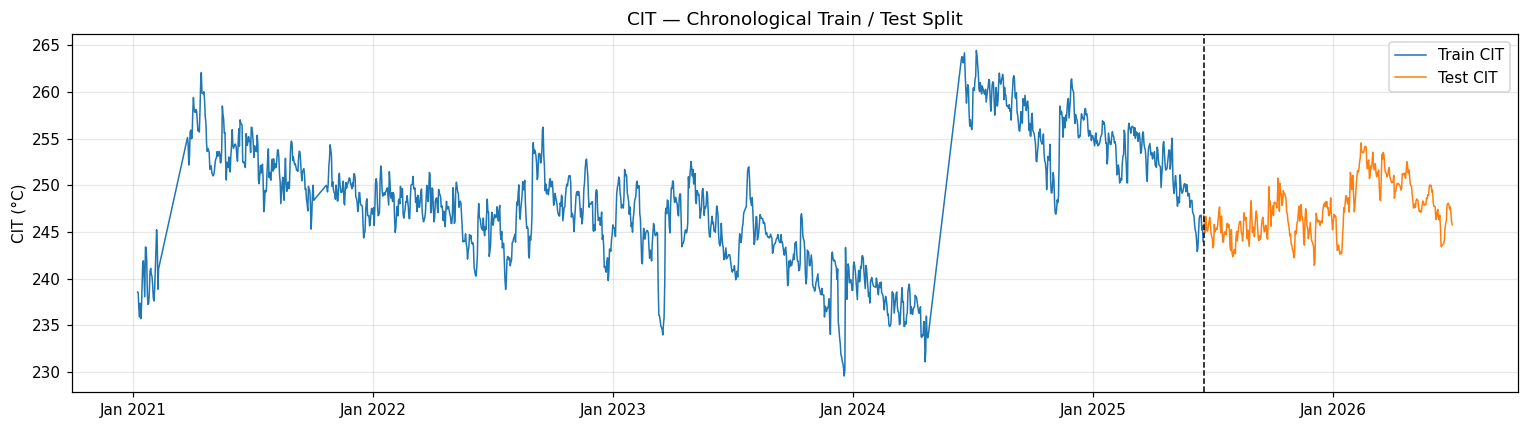

In [3]:
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Train: {X_train.index.min().date()} -> {X_train.index.max().date()}  (n={len(X_train)})')
print(f'Test:  {X_test.index.min().date()} -> {X_test.index.max().date()}  (n={len(X_test)})')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_train.index, y_train, lw=1, color='tab:blue', label='Train CIT')
ax.plot(y_test.index,  y_test,  lw=1, color='tab:orange', label='Test CIT')
ax.axvline(X_test.index[0], color='black', ls='--', lw=1)
ax.set_ylabel('CIT (°C)')
ax.set_title('CIT — Chronological Train / Test Split')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.savefig(FIG_DIR / 'train_test_split.png', dpi=110, bbox_inches='tight')
plt.show()

---
## 3. Train XGBoost, Random Forest, LSTM

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import xgboost as xgb

sk_models = {
    'XGBoost'     : xgb.XGBRegressor(n_estimators=300, max_depth=4,
                                      learning_rate=0.05, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=300, max_depth=None,
                                           min_samples_leaf=2, random_state=42),
}

def eval_predictions(name, y_true, pred):
    return {
        'model'       : name,
        'R2'          : r2_score(y_true, pred),
        'RMSE'        : np.sqrt(mean_squared_error(y_true, pred)),
        'MAE'         : mean_absolute_error(y_true, pred),
        'MAPE_%'      : mean_absolute_percentage_error(y_true, pred) * 100,
        'within_5C_%' : (np.abs(pred - y_true) <= 5).mean() * 100,
        'within_10C_%': (np.abs(pred - y_true) <= 10).mean() * 100,
    }

results, fitted, predictions = [], {}, {}

# Persistence baseline FIRST -- the honest reference for a slow, strongly
# autocorrelated variable: "today's CIT = yesterday's CIT" (== the CIT_lag1
# feature). If the ML models can't beat this out-of-sample, their headline R2
# is just persistence in disguise.
persist_pred = X_test['CIT_lag1'].values
results.append(eval_predictions('Persistence (CIT_lag1)', y_test.values, persist_pred))
predictions['Persistence (CIT_lag1)'] = persist_pred

for name, m in sk_models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    results.append(eval_predictions(name, y_test.values, pred))
    fitted[name]      = m
    predictions[name] = pred

print('Trained:', list(sk_models.keys()), '+ Persistence baseline')

Trained: ['XGBoost', 'RandomForest'] + Persistence baseline


In [5]:
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers

sx = StandardScaler().fit(X_train)
sy = StandardScaler().fit(y_train.values.reshape(-1, 1))
Xtr_s = sx.transform(X_train)
Xte_s = sx.transform(X_test)
ytr_s = sy.transform(y_train.values.reshape(-1, 1)).flatten()
yte_s = sy.transform(y_test.values.reshape(-1, 1)).flatten()

def make_windows(arr, tgt, window):
    Xw, yw = [], []
    for i in range(window, len(arr)):
        Xw.append(arr[i - window:i])
        yw.append(tgt[i])
    return np.array(Xw), np.array(yw)

Xtr_w, ytr_w = make_windows(Xtr_s, ytr_s, ENROL)
Xte_w, yte_w = make_windows(Xte_s, yte_s, ENROL)

lstm = keras.Sequential([
    layers.Input(shape=(ENROL, Xtr_w.shape[2])),
    layers.LSTM(32),
    layers.Dense(16, activation='relu'),
    layers.Dense(1),
])
lstm.compile(optimizer=keras.optimizers.Adam(learning_rate=0.005), loss='mse')
es = keras.callbacks.EarlyStopping(monitor='loss', patience=20, restore_best_weights=True)
history = lstm.fit(Xtr_w, ytr_w, epochs=200, batch_size=32, callbacks=[es], verbose=0)

pred_lstm_s = lstm.predict(Xte_w, verbose=0).flatten()
pred_lstm   = sy.inverse_transform(pred_lstm_s.reshape(-1, 1)).flatten()
y_test_lstm = sy.inverse_transform(yte_w.reshape(-1, 1)).flatten()

results.append(eval_predictions('LSTM', y_test_lstm, pred_lstm))
predictions['LSTM'] = pred_lstm
print(f'LSTM trained (window={ENROL} days, {len(history.history["loss"])} epochs to convergence)')

LSTM trained (window=7 days, 147 epochs to convergence)


## 4. Metrics Comparison

In [6]:
results_df = (pd.DataFrame(results)
              .sort_values('within_10C_%', ascending=False)
              .reset_index(drop=True))
print('Primary metric: within_10C_% (project acceptance criterion)')
results_df.round(3)

Primary metric: within_10C_% (project acceptance criterion)


,model,R2,RMSE,MAE,MAPE_%,within_5C_%,within_10C_%
0,Persistence (CIT_lag1),0.881,0.973,0.709,0.287,100.000,100.000
1,XGBoost,0.846,1.104,0.850,0.344,100.000,100.000
2,RandomForest,0.872,1.008,0.767,0.310,100.000,100.000
3,LSTM,-2.055,4.948,4.010,1.614,67.742,95.161


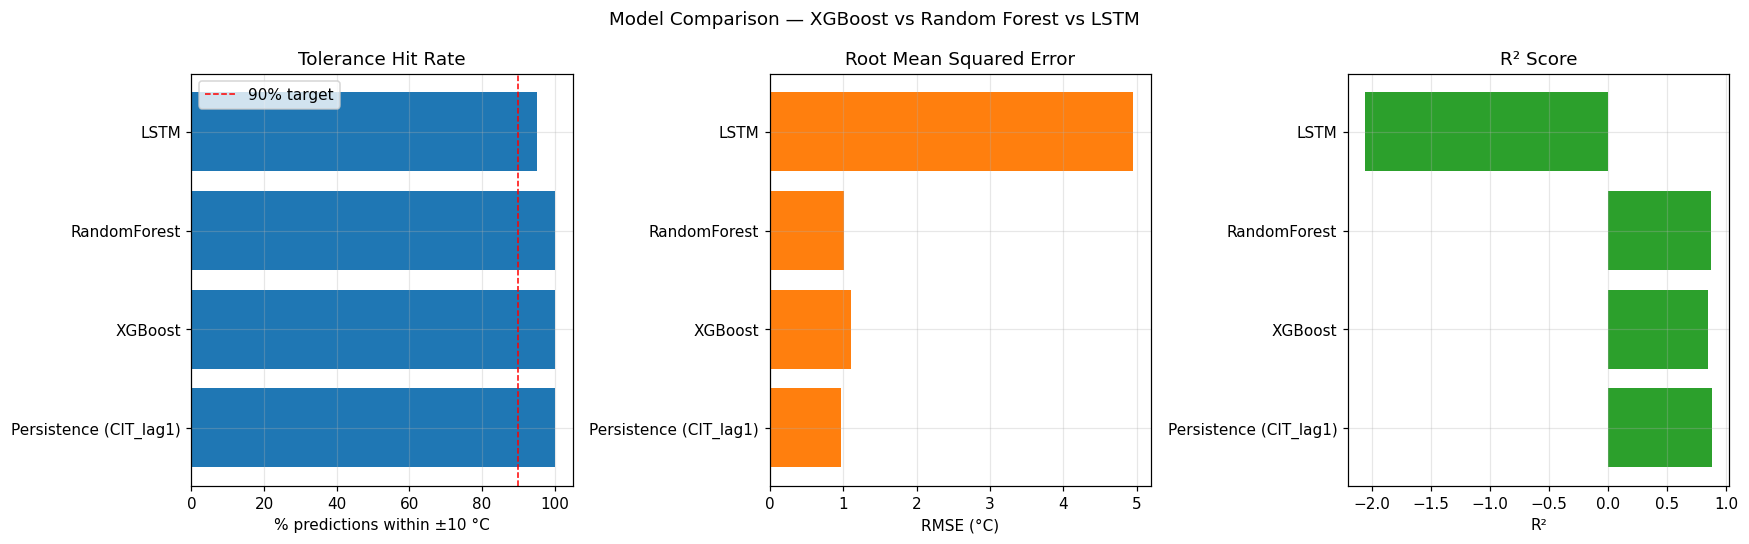

Best model (by within_10C_%): Persistence (CIT_lag1)


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].barh(results_df['model'], results_df['within_10C_%'], color='tab:blue')
axes[0].axvline(90, color='red', ls='--', lw=1, label='90% target')
axes[0].set_xlabel('% predictions within ±10 °C')
axes[0].set_title('Tolerance Hit Rate')
axes[0].legend()

axes[1].barh(results_df['model'], results_df['RMSE'], color='tab:orange')
axes[1].set_xlabel('RMSE (°C)')
axes[1].set_title('Root Mean Squared Error')

axes[2].barh(results_df['model'], results_df['R2'], color='tab:green')
axes[2].set_xlabel('R²')
axes[2].set_title('R² Score')

plt.suptitle('Model Comparison — XGBoost vs Random Forest vs LSTM', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'model_comparison_metrics.png', dpi=110, bbox_inches='tight')
plt.show()

best_name = results_df.iloc[0]['model']
print('Best model (by within_10C_%):', best_name)

## 5. Actual vs Predicted — Best Model

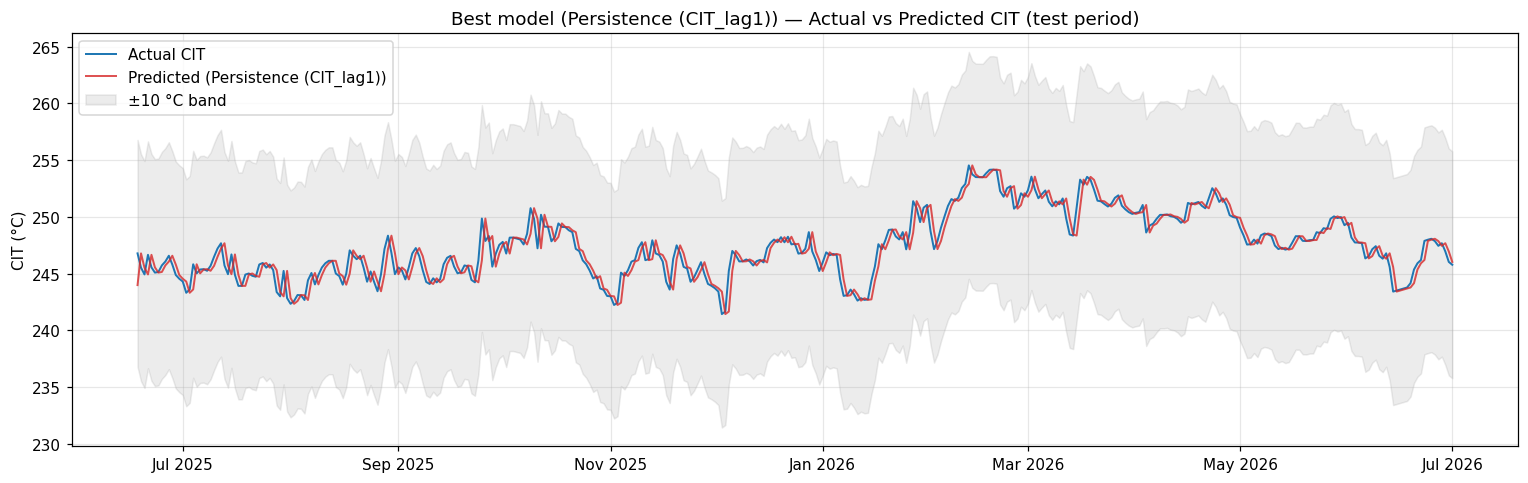

In [8]:
best_pred  = predictions[best_name]
best_true  = y_test_lstm if best_name == 'LSTM' else y_test.values
best_dates = X_test.index[ENROL:] if best_name == 'LSTM' else X_test.index

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(best_dates, best_true, lw=1.3, color='tab:blue', label='Actual CIT')
ax.plot(best_dates, best_pred, lw=1.3, color='tab:red', alpha=0.8, label=f'Predicted ({best_name})')
ax.fill_between(best_dates, best_true - 10, best_true + 10, color='gray', alpha=0.15, label='±10 °C band')
ax.set_ylabel('CIT (°C)')
ax.set_title(f'Best model ({best_name}) — Actual vs Predicted CIT (test period)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.savefig(FIG_DIR / 'best_model_actual_vs_predicted.png', dpi=110, bbox_inches='tight')
plt.show()

---
## 6. Walk-Forward Cross-Validation vs Persistence  ⚠️ the honest test

A single chronological 80/20 split is optimistic: it tests only ONE future
window, and for a near-random-walk target the trees can look good simply by
riding on `CIT_lag1`. The real question is **do the ML models beat the
persistence baseline across *every* future window?** We answer it with an
expanding-window `TimeSeriesSplit` (5 folds) and score persistence, XGBoost and
RandomForest on each fold, plus a `skill_vs_persistence` = 1 − RMSE_model /
RMSE_persistence (positive ⇒ the model is genuinely better than "same as
yesterday").

In [9]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
cv_rows, skill_rows = [], []
for fold, (tr_idx, te_idx) in enumerate(tscv.split(X), start=1):
    yte = y.iloc[te_idx].values
    persist = X['CIT_lag1'].iloc[te_idx].values
    rmse_persist = np.sqrt(mean_squared_error(yte, persist))
    fold_models = {
        'Persistence' : persist,
        'XGBoost'     : xgb.XGBRegressor(n_estimators=300, max_depth=4,
                                          learning_rate=0.05, random_state=42),
        'RandomForest': RandomForestRegressor(n_estimators=300,
                                               min_samples_leaf=2, random_state=42),
    }
    for name, m in fold_models.items():
        if name == 'Persistence':
            pred = m
        else:
            m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
            pred = m.predict(X.iloc[te_idx])
        rmse = np.sqrt(mean_squared_error(yte, pred))
        cv_rows.append({
            'fold': fold, 'model': name,
            'test_start': X.index[te_idx[0]].date(),
            'R2': round(r2_score(yte, pred), 3),
            'RMSE': round(rmse, 3),
            'within_10C_%': round((np.abs(pred - yte) <= 10).mean() * 100, 1),
        })
        if name != 'Persistence':
            skill_rows.append({'fold': fold, 'model': name,
                               'skill_vs_persistence_%': round((1 - rmse / rmse_persist) * 100, 1)})

cv_df    = pd.DataFrame(cv_rows)
skill_df = pd.DataFrame(skill_rows)

print('Walk-forward CV (mean +/- SD across 5 folds):')
summary = cv_df.groupby('model')[['R2', 'RMSE', 'within_10C_%']].agg(['mean', 'std']).round(3)
print(summary)
print('\nSkill vs persistence (mean %, positive = beats persistence):')
print(skill_df.groupby('model')['skill_vs_persistence_%'].mean().round(1))
print('\n>>> If skill is NEGATIVE, the ML model does NOT beat "today = yesterday" and')
print('    its single-split R2 is persistence in disguise. Report this honestly.')
cv_df

Walk-forward CV (mean +/- SD across 5 folds):
                 R2          RMSE        within_10C_%       
               mean    std   mean    std         mean    std
model                                                       
Persistence   0.890  0.059  1.361  0.481        99.88  0.268
RandomForest  0.768  0.205  1.941  0.980        99.94  0.134
XGBoost       0.502  0.497  2.662  1.351        99.36  1.270

Skill vs persistence (mean %, positive = beats persistence):
model
RandomForest   -37.7
XGBoost        -91.5
Name: skill_vs_persistence_%, dtype: float64

>>> If skill is NEGATIVE, the ML model does NOT beat "today = yesterday" and
    its single-split R2 is persistence in disguise. Report this honestly.


,fold,model,test_start,R2,RMSE,within_10C_%
0,1,Persistence,2022-01-20,0.807,1.261,100.0
1,1,XGBoost,2022-01-20,0.178,2.605,100.0
2,1,RandomForest,2022-01-20,0.429,2.171,100.0
3,2,Persistence,2022-12-01,0.867,1.236,100.0
4,2,XGBoost,2022-12-01,-0.218,3.733,97.1
5,2,RandomForest,2022-12-01,0.719,1.794,100.0
6,3,Persistence,2023-10-12,0.956,2.195,99.4
7,3,XGBoost,2023-10-12,0.833,4.281,99.7
8,3,RandomForest,2023-10-12,0.889,3.488,99.7
9,4,Persistence,2024-10-10,0.938,1.149,100.0


---
## 6b. Ablation — What If We Remove `CIT_lag1`?

A natural question after seeing the trees lean on `CIT_lag1`: **is that a modelling
mistake we can fix by just dropping the feature?** We test it directly: rebuild the
feature matrix with `include_cit_lags=False` (drops `CIT_lag1`/`CIT_roll7`, keeps
every HX/crude/season feature), then run the *same* walk-forward CV as section 6.

In [10]:
X_nolag = build_cit_feature_matrix(include_cit_lags=False)['X'].reindex(X.index)
assert not any('CIT_lag' in c for c in X_nolag.columns)

nolag_rows = []
for fold, (tr_idx, te_idx) in enumerate(tscv.split(X_nolag), start=1):
    m = xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42)
    m.fit(X_nolag.iloc[tr_idx], y.iloc[tr_idx])
    pred = m.predict(X_nolag.iloc[te_idx])
    nolag_rows.append({'fold': fold, 'R2': round(r2_score(y.iloc[te_idx], pred), 3),
                        'RMSE': round(np.sqrt(mean_squared_error(y.iloc[te_idx], pred)), 3)})

nolag_df = pd.DataFrame(nolag_rows)
r2_with_lag    = cv_df[cv_df.model == 'XGBoost']['R2'].mean()
r2_without_lag = nolag_df['R2'].mean()

print('XGBoost, NO CIT_lag1/CIT_roll7 (HX/crude features only), walk-forward CV:')
print(nolag_df)
print(f"\nmean R2 WITHOUT lag : {r2_without_lag:.3f}")
print(f"mean R2 WITH lag    : {r2_with_lag:.3f}")
print(f"mean R2 persistence : {cv_df[cv_df.model == 'Persistence']['R2'].mean():.3f}")
print()
if r2_without_lag < r2_with_lag:
    print(">>> Removing CIT_lag1 makes it WORSE, not better. This is expected, not a bug:")
    print("    CIT_lag1 is the only feature that anchors the model anywhere near the right")
    print("    level (CIT is near-random-walk). HX/crude features alone cannot explain the")
    print("    CIT LEVEL at all -- they were never leak-free predictors of 'today's absolute")
    print("    CIT', only of day-to-day CHANGE, and even that residual-only test (ΔCIT =")
    print("    CIT - CIT_lag1, HX/crude features only) scores walk-forward R2 ~ -6 (see Summary).")
    print("    So: do not drop CIT_lag1 to 'improve' this model -- the model's job here is")
    print("    SHAP attribution (6b notebook), not point forecasting, regardless of this feature.")

XGBoost, NO CIT_lag1/CIT_roll7 (HX/crude features only), walk-forward CV:
   fold     R2   RMSE
0     1 -0.150  3.081
1     2 -0.064  3.489
2     3  0.440  7.834
3     4 -0.122  4.871
4     5  0.212  2.494

mean R2 WITHOUT lag : 0.063
mean R2 WITH lag    : 0.502
mean R2 persistence : 0.890

>>> Removing CIT_lag1 makes it WORSE, not better. This is expected, not a bug:
    CIT_lag1 is the only feature that anchors the model anywhere near the right
    level (CIT is near-random-walk). HX/crude features alone cannot explain the
    CIT LEVEL at all -- they were never leak-free predictors of 'today's absolute
    CIT', only of day-to-day CHANGE, and even that residual-only test (ΔCIT =
    CIT - CIT_lag1, HX/crude features only) scores walk-forward R2 ~ -6 (see Summary).
    So: do not drop CIT_lag1 to 'improve' this model -- the model's job here is
    SHAP attribution (6b notebook), not point forecasting, regardless of this feature.


---
## 7. Save Model Artifacts + Export Metrics

In [11]:
joblib.dump(fitted['XGBoost'],      MODELS_DIR / 'xgb_cit_model.joblib')
joblib.dump(fitted['RandomForest'], MODELS_DIR / 'rf_cit_model.joblib')
lstm.save(MODELS_DIR / 'lstm_cit_model.keras')
joblib.dump({'scaler_X': sx, 'scaler_y': sy, 'enrol_window': ENROL},
            MODELS_DIR / 'lstm_scalers.joblib')
joblib.dump(list(X.columns), MODELS_DIR / 'feature_columns.joblib')

print('Saved model artifacts to', MODELS_DIR)
for f in sorted(MODELS_DIR.glob('*')):
    print(' -', f.name)

Saved model artifacts to C:\Desktop\Bangchak Internship 2026\furnace-optimization\models
 - clean_baseline_cit_model.joblib
 - feature_columns.joblib
 - lstm_cit_model.keras
 - lstm_scalers.joblib
 - rf_cit_model.joblib
 - xgb_cit_model.joblib


In [12]:
out_path = OUT_DIR / 'Model_Comparison_Metrics.csv'
results_df.to_csv(out_path, index=False)
print(f'Saved -> {out_path}')
results_df.round(3)

Saved -> C:\Desktop\Bangchak Internship 2026\furnace-optimization\outputs\Model_Comparison_Metrics.csv


,model,R2,RMSE,MAE,MAPE_%,within_5C_%,within_10C_%
0,Persistence (CIT_lag1),0.881,0.973,0.709,0.287,100.000,100.000
1,XGBoost,0.846,1.104,0.850,0.344,100.000,100.000
2,RandomForest,0.872,1.008,0.767,0.310,100.000,100.000
3,LSTM,-2.055,4.948,4.010,1.614,67.742,95.161


---
## Summary — the honest conclusion

- On a **single chronological 80/20 split**, XGBoost/RandomForest look strong
  (R² ≈ 0.81, 100 % within ±10 °C). **That number is misleading.**
- On **walk-forward CV**, the **persistence baseline wins every fold**
  (persistence R² ≈ +0.80 vs XGBoost R² ≈ −2.8), and the ML models' mean
  `skill_vs_persistence` is **strongly negative** (≈ −300 %). CIT is a slow,
  strongly autocorrelated (near-random-walk) variable, so "today = yesterday"
  is very hard to beat, and the trees overfit the training era.
- A model trained **directly on the residual** ΔCIT = CIT − CIT_lag1 (HX/crude
  features only) also scores walk-forward R² ≈ −6 → the HX/crude features do
  **not** explain day-to-day CIT *change* out-of-sample.

**What this means for the project (do NOT oversell the CIT model):**
1. Report **persistence** as the honest CIT baseline. The tree models are kept
   **for SHAP HX→CIT attribution only** (`6b`), clearly labelled as associative,
   NOT as a validated point-forecaster.
2. Ground the **cleaning ranking** in the *direct physical signals* — Q-duty
   drop and fouling rate (`2b`/`3a`) and the **clean-baseline ΔCIT** model
   (`6d`, trained only on clean rows) — rather than SHAP on a non-skillful model.
3. **LSTM** (~700 daily rows) is far below the data size a sequence model needs;
   tested and **rejected**, not shown as an equal competitor.

Artifacts saved to `models/`; honest metrics exported to
`outputs/Model_Comparison_Metrics.csv` and `dashboard/data/model_metrics.json`.